In [2]:
import numpy as np
from scipy import signal
from scipy.fft import fft, fftshift
import matplotlib.pyplot as plt

In [6]:
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    """
    Filter swot_image with a gaussian filter
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter)
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction time step
        dy : float, y direction time step
    """
    from scipy.ndimage import convolve1d
    import scipy.signal.windows as wdw
    
    # Gaussian a la mano
    lambda_cutoff = cutoff/dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4*lambda_cutoff)+1)
    gaussian = wdw.gaussian(Mg, std = sigma_cutoff)
    fg = xr.DataArray(convolve1d(convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1), dims=swot_image.dims)#unnromalized
    fm = xr.DataArray(convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims)#unnormalized
    return xr.DataArray(fg/fm, dims=swot_image.dims)#normalized

In [43]:
def mean_std(x, y):
    mean = sum(x*y)/sum(y)
    return mean, np.sqrt(  sum(y*x**2)/sum(y) -mean**2)

In [78]:
x= np.arange(-50, 51, 1)
N=len(x)

(7.216142740520787e-17, 6.999999999903491)

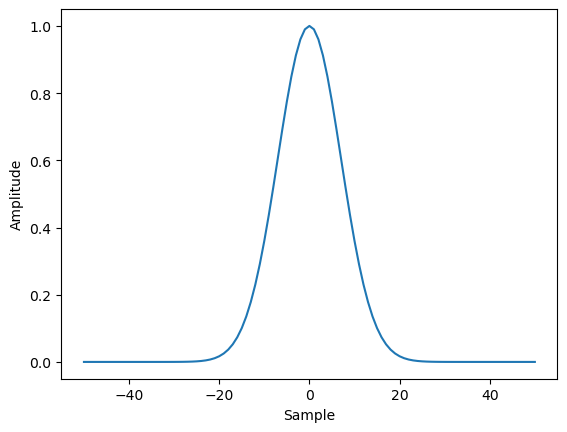

In [80]:
gwindow = signal.windows.gaussian(N, std=7)
plt.plot(x, gwindow)
#plt.title(r"Gaussian window ($\sigma$=7)")
plt.ylabel("Amplitude")
plt.xlabel("Sample")
mean, std = mean_std(x, gwindow)
mean, std

29


ValueError: x and y must have same first dimension, but have shapes (101,) and (29,)

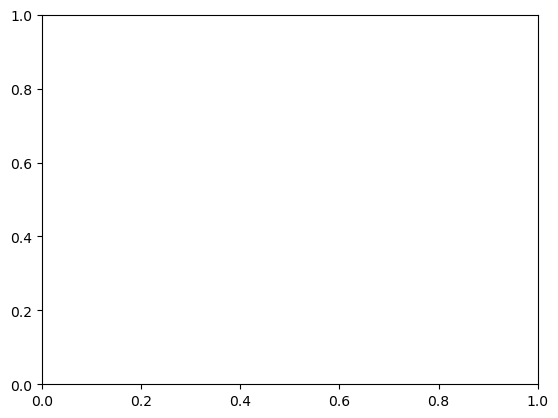

In [81]:
std=1
NP = int(N*c)
print(NP)
xp = np.linspace(-50, 51, N)
pwindow = signal.windows.parzen(NP)
plt.plot(xp, window)
plt.title("Parzen window")
plt.ylabel("Amplitude")
plt.xlabel("Sample")
mean, std = mean_std(xp, window)
mean, std

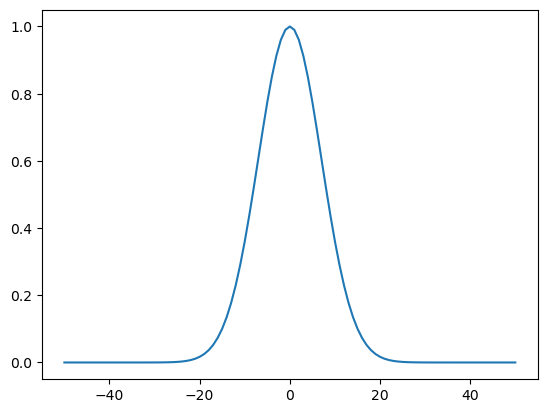

In [76]:
plt.plot(x, gwindow)
#plt.plot(xp, pwindow)

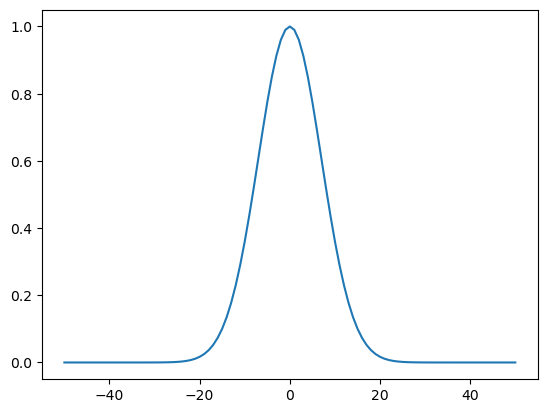

In [76]:
plt.plot(x, gwindow)
#plt.plot(xp, pwindow)

In [66]:
c = 0.2915618743495535

Text(0.5, 0, 'Sample')

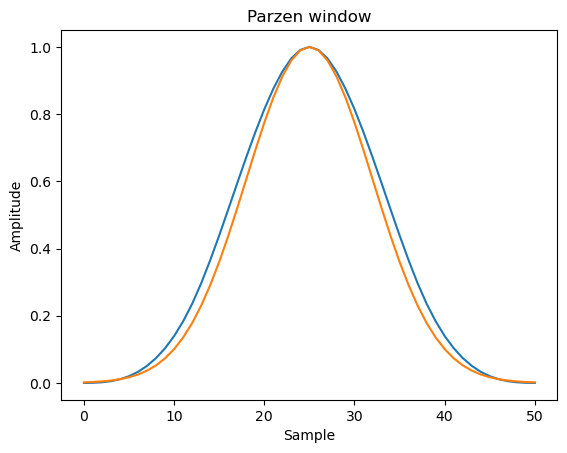

In [25]:
window = signal.windows.parzen(51)
plt.plot(window)
plt.title("Parzen window")
plt.ylabel("Amplitude")
plt.xlabel("Sample")

window = signal.windows.gaussian(51, std=7)
plt.plot(window)
#plt.title(r"Gaussian window ($\sigma$=7)")
plt.ylabel("Amplitude")
plt.xlabel("Sample")

In [21]:
W = []
STD = []
for i in range(10, 100, 1):
    W.append(signal.windows.parzen(i))
    STD.append(signal.windows.parzen(i).std())

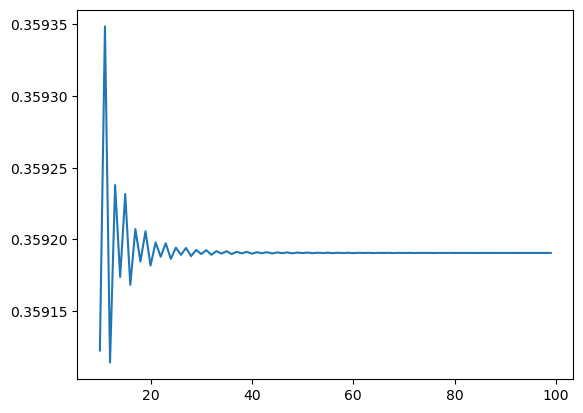

In [22]:
plt.plot(np.arange(10, 100), STD)

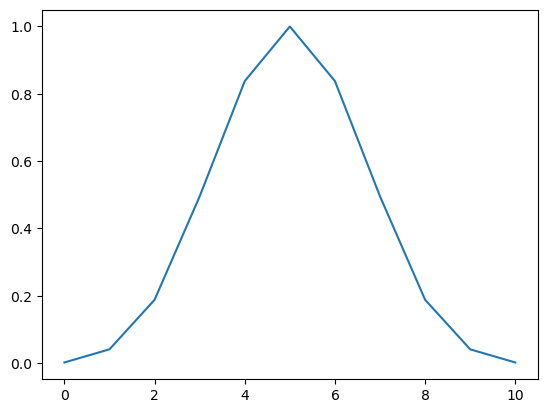

In [23]:
plt.plot(W[1])